In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl

In [3]:
# Load input and template images
img_bgr = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\Data_test\20250620_143025.bmp")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Using OpenCV to ensure correct format
template_bgr = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\Data\2025-06-20\OK\raw_image\20250620_095446.bmp")
template_rgb = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2RGB)
cropped_template_gray = cv2.cvtColor(template_rgb, cv2.COLOR_RGB2GRAY)
height, width = cropped_template_gray.shape

In [43]:
def downscale_image(img, levels):
    for _ in range(levels):
        img = cv2.pyrDown(img)
    return img
def run_without_rotate(img_gray, template):
    scale_factor = 2 ** 1

    # Downscale both image and template
    down_gray = downscale_image(img_gray, 1)
    down_template = downscale_image(template, 1)

    # Ensure template size is smaller than image
    if down_gray.shape[0] < down_template.shape[0] or down_gray.shape[1] < down_template.shape[1]:
        raise ValueError("Template size is larger than the downscaled image")

    # Perform template matching
    res = cv2.matchTemplate(down_gray, down_template, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, max_loc = cv2.minMaxLoc(res)

    # Match location (scaled back to original image size)
    top_left = (int(max_loc[0] * scale_factor), int(max_loc[1] * scale_factor))
    bottom_right = (
        int((max_loc[0] + down_template.shape[1]) * scale_factor),
        int((max_loc[1] + down_template.shape[0]) * scale_factor)
    )

    # Clamp values to image boundaries
    x1 = max(0, top_left[0])
    y1 = max(0, top_left[1])
    x2 = min(img_gray.shape[1], bottom_right[0])
    y2 = min(img_gray.shape[0], bottom_right[1])

    return [x1, y1, x2, y2]

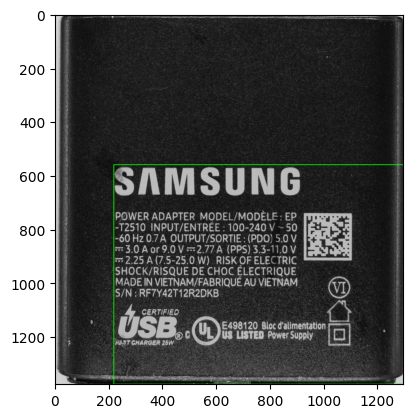

In [ ]:
import cv2
import numpy as np

# Load main image and template in grayscale
image = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\Data\2025-06-28\OK\raw_image\20250628_111419.bmp", cv2.IMREAD_GRAYSCALE)
template = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\template\temp3.bmp", cv2.IMREAD_GRAYSCALE)

# Store width and height of template
w, h = template.shape[::-1]

a = run_without_rotate(image, template)

matched_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.rectangle(matched_img, (a[0], a[1]), (a[2], a[3]), (0, 255, 0), 2)
plt.imshow(matched_img)
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import os
from matplotlib import pyplot as plt

def downscale_image(img, levels):
    for _ in range(levels):
        img = cv.pyrDown(img)
    return img

def rotate_image(image, angle):
    (h, w) = image.shape
    center = (w // 2, h // 2)
    rot_mat = cv.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv.warpAffine(image, rot_mat, (w, h), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_REPLICATE)
    return rotated

# --- Set Paths ---
folder_path = r"D:\Charger_Defect_Detection_Realtime\Data\2025-06-28\OK\raw"
# template_path = r"D:\Charger_Defect_Detection_Realtime\template\Image_20250627113536388.bmp"
template_path = r"D:\Charger_Defect_Detection_Realtime\template\temp_5.bmp"


# --- Load template image ---
template = cv.imread(template_path, cv.IMREAD_GRAYSCALE)
assert template is not None, "Template could not be read"

# --- Parameters ---
levels = 0
scale_factor = 2 ** levels

# --- Loop through images in folder ---
for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg')):
        continue

    img_path = os.path.join(folder_path, filename)
    img_rgb = cv.imread(img_path)
    if img_rgb is None:
        print(f"❌ Failed to read: {filename}")
        continue

    img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
    img_gray = img_gray[300:2800, 800:3000]

    # img_gray = cv.GaussianBlur(img_gray, (3, 3), 0)
    # template = cv.GaussianBlur(template, (3, 3), 0)
    
    best_score = -1
    # best_score = float('inf')  # Because we're minimizing
    best_angle = 0
    best_top_left = (0, 0)


    for angle in np.arange(-5, 6, 0.5):  # Step by 0.5°
        rotated = rotate_image(img_gray, angle)
        down_gray = downscale_image(rotated, levels)
        down_template = downscale_image(template, levels)

        res = cv.matchTemplate(down_gray, down_template, cv.TM_CCORR_NORMED)
        # res = cv.matchTemplate(down_gray, down_template, cv.TM_SQDIFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
        # _, max_val, _, max_loc = cv.minMaxLoc(res)

        if max_val > best_score:
            best_score = max_val
            best_angle = angle
            best_top_left = max_loc
        
        # if min_val < best_score:
        #     best_score = min_val
        #     best_angle = angle
        #     best_top_left = min_loc
    # Final match
    best_rotated_gray = rotate_image(img_gray, best_angle)
    top_left = (best_top_left[0] * scale_factor, best_top_left[1] * scale_factor)
    bottom_right = ((best_top_left[0] + down_template.shape[1]) * scale_factor,
                    (best_top_left[1] + down_template.shape[0]) * scale_factor)

    x1, y1 = max(0, top_left[0]), max(0, top_left[1])
    x2, y2 = min(best_rotated_gray.shape[1], bottom_right[0]), min(best_rotated_gray.shape[0], bottom_right[1])
    # if best_score > 0.7:
    # if best_score  < 0.1:
    print(best_angle)
    cropped = best_rotated_gray[int(y1):int(y2), int(x1):int(x2)]
    plt.imshow(cropped, cmap='gray')
    plt.show()

In [6]:
print("Image shape:", img_gray.shape)
print("Template shape:", template_gray.shape)

Image shape: (3000, 4096)
Template shape: (965, 920)


In [144]:
from ultralytics import YOLO
import cv2
import numpy as np

class AdapterDetectionModel:
    def __init__(self):
        self.model = YOLO('D:/Charger_Defect_Detection_Realtime/weights/best_yolov12n_train65_adapter_v0.2.pt')
        self.test_with_dummy_image()
        self.template = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\notebooks\template_2.bmp", cv2.IMREAD_GRAYSCALE)
    
    def test_with_dummy_image(self):
        dummy_img = np.full((640, 640, 3), 255, dtype=np.uint8)
        self.model(dummy_img)
        print("Detection model preloaded successfully")

    def detecting(self, image):
        raw_image = image.copy()
        rgb_image = cv2.cvtColor(raw_image, cv2.COLOR_GRAY2RGB)
        
        results = self.model(rgb_image)
        result = results[0]
        
        # Draw bounding boxes
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = result.names[cls_id]
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw rectangle and label
            cv2.rectangle(rgb_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"{class_name} {conf:.2f}"
            cv2.putText(rgb_image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255, 0, 0), 2)

        return result, rgb_image
    
    @staticmethod
    def downscale_image(img, levels):
        for _ in range(levels):
            img = cv2.pyrDown(img)  # Fixed: cv2 instead of cv
        return img

    @staticmethod
    def rotate_image(image, angle):
        h, w = image.shape[:2]  # Fixed: get dimensions from image
        center = (w // 2, h // 2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(image, rot_mat, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        return rotated

    def match_template(self, img_gray):
        # Ensure input is 2D grayscale
        if len(img_gray.shape) == 3:
            # Only convert if it's actually a 3-channel image
            if img_gray.shape[2] == 3:
                img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)
            elif img_gray.shape[2] == 1:
                # If it's a 3D array with 1 channel, squeeze to 2D
                img_gray = img_gray.squeeze()
        
        h, w = img_gray.shape[:2]
        
        levels = 4
        scale_factor = 2 ** levels
        best_score = -1
        best_angle = 0
        best_top_left = (0, 0)

        for angle in range(-15, 16, 1):
            rotated = self.rotate_image(img_gray, angle)
            down_gray = self.downscale_image(rotated, levels)
            down_template = self.downscale_image(self.template, levels)

            res = cv2.matchTemplate(down_gray, down_template, cv2.TM_CCOEFF_NORMED)
            _, max_val, _, max_loc = cv2.minMaxLoc(res)

            if max_val > best_score:
                best_score = max_val
                best_angle = angle
                best_top_left = max_loc

        best_rotated_gray = self.rotate_image(img_gray, best_angle)
        print("Angle: ",best_angle)
        top_left = (best_top_left[0] * scale_factor, best_top_left[1] * scale_factor)
        bottom_right = ((best_top_left[0] + down_template.shape[1]) * scale_factor,
                        (best_top_left[1] + down_template.shape[0]) * scale_factor)

        x1, y1 = map(int, top_left)
        x2, y2 = map(int, bottom_right)

        h, w = best_rotated_gray.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        # Ensure we have valid coordinates
        if x2 <= x1 or y2 <= y1:
            print("Warning: Invalid crop coordinates, returning original image")
            return img_gray

        cropped = best_rotated_gray[y1:y2, x1:x2]
        plt.figure(figsize=(5, 4))
        plt.imshow(cropped)
        plt.axis('off')
        plt.show()
        # Create padded match with same dimensions and type as input
        padded_match = np.zeros_like(img_gray)
        
        # Ensure cropped region fits within the padded_match bounds
        crop_h, crop_w = cropped.shape[:2]
        target_h = min(crop_h, padded_match.shape[0] - y1)
        target_w = min(crop_w, padded_match.shape[1] - x1)
        
        if target_h > 0 and target_w > 0:
            padded_match[y1:y1+target_h, x1:x1+target_w] = cropped[:target_h, :target_w]
        
        return padded_match

    def crop_adapter(self, result, image):
        adapter_crop = None
        rgb_image = image.copy()
        
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = result.names[cls_id]
            if class_name == "Adapter":
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                adapter_crop = rgb_image[y1:y2, x1:x2]
                break    
        return adapter_crop
    
    def find_offset(self, result, image):
        adapter_bbox = []
        text_bbox = []
        
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = result.names[cls_id]
            if class_name == "Adapter":
                adapter_bbox = box.xyxy[0]
            elif class_name == "Text_Area":
                text_bbox = box.xyxy[0]
                
        if len(adapter_bbox) == 0 or len(text_bbox) == 0:
            print("Warning: Adapter or Text_Area not found")
            return image
            
        x0, y0, x1, y1 = map(int, adapter_bbox)
        x2, y2, x3, y3 = map(int, text_bbox)
        
        d_left   = x2 - x0
        d_top    = y2 - y0
        d_right  = x1 - x3
        d_bottom = y1 - y3
        print(f"adapter: {adapter_bbox} - text_box: {text_bbox}")
        # print(f"Distance: Left: {d_left} -- Top: {d_top} -- Right: {d_right} -- Bottom: {d_bottom}")
        print(f"Distance: Left: {d_left} -- Bottom: {d_bottom}")
        
        return image


0: 640x640 (no detections), 52.0ms
Speed: 1.7ms preprocess, 52.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Detection model preloaded successfully


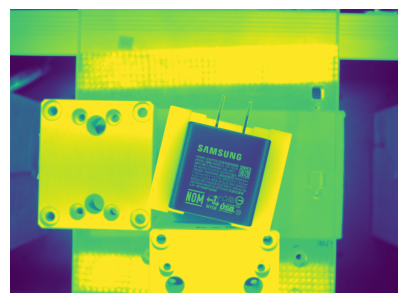

Angle:  13


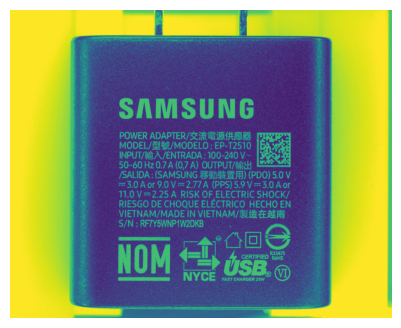


0: 480x640 1 Adapter, 1 Text_Area, 51.3ms
Speed: 1.9ms preprocess, 51.3ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
adapter: tensor([1808.3555, 1174.4963, 2732.9758, 2175.3569]) - text_box: tensor([1960.8199, 1431.5237, 2576.4370, 2080.6194])
Distance: Left: 152 -- Bottom: 95


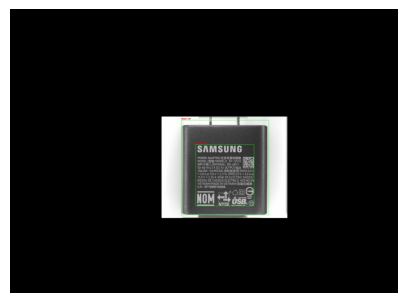

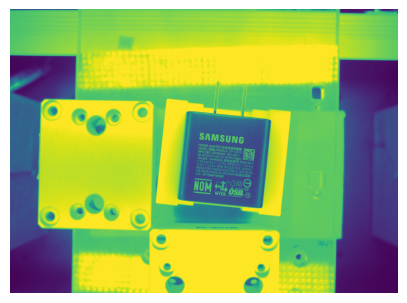

Angle:  6


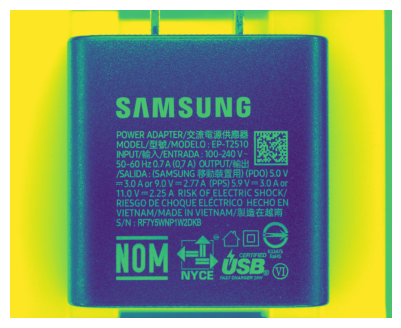


0: 480x640 1 Adapter, 1 Text_Area, 52.1ms
Speed: 1.7ms preprocess, 52.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
adapter: tensor([1820.9625, 1078.2913, 2731.6265, 2046.9655]) - text_box: tensor([1969.9988, 1302.6855, 2578.5754, 1946.5554])
Distance: Left: 149 -- Bottom: 100


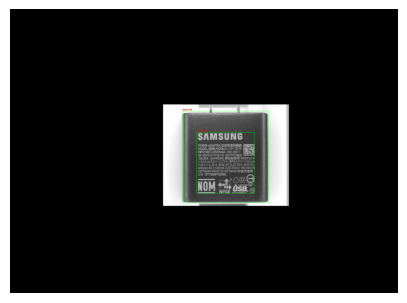

In [145]:
import os
import cv2
import matplotlib.pyplot as plt

adapter_model = AdapterDetectionModel()

folder_path = "D:/Charger_Defect_Detection_Realtime/Data_test"
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]

for i, filename in enumerate(image_files):
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    img_crop = adapter_model.match_template(img)
    adapter_result, rgb_image = adapter_model.detecting(img_crop)
    crop_img = adapter_model.crop_adapter(adapter_result, rgb_image)
    image = adapter_model.find_offset(adapter_result, rgb_image)
    # copy_crop_img = crop_img.copy()
    # print(adapter_result)
    plt.figure(figsize=(5, 4))
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()
    # plt.imshow(crop_img)
    # plt.axis('off')
    # plt.show()


In [112]:
from ultralytics import YOLO
import cv2
import numpy as np

class AdapterDetectionModel:
    def __init__(self):
        self.model = YOLO('D:/Charger_Defect_Detection_Realtime/weights/best_yolov12n_train65_adapter_v0.2.pt')
        self.test_with_dummy_image()
        self.template = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\notebooks\template_2.bmp", cv2.IMREAD_GRAYSCALE)
        self.template_2 = cv2.imread(r"D:\Charger_Defect_Detection_Realtime\notebooks\template.bmp", cv2.IMREAD_GRAYSCALE)
    def test_with_dummy_image(self):
        dummy_img = np.full((640, 640, 3), 255, dtype=np.uint8)
        self.model(dummy_img)
        print("Detection model preloaded successfully")

    def detecting(self, image):
        raw_image = image.copy()
        rgb_image = cv2.cvtColor(raw_image, cv2.COLOR_GRAY2RGB)
        
        results = self.model(rgb_image)
        result = results[0]
        
        # Draw bounding boxes
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = result.names[cls_id]
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw rectangle and label
            cv2.rectangle(rgb_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"{class_name} {conf:.2f}"
            cv2.putText(rgb_image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255, 0, 0), 2)

        return result, rgb_image
    
    @staticmethod
    def downscale_image(img, levels):
        for _ in range(levels):
            img = cv2.pyrDown(img)  # Fixed: cv2 instead of cv
        return img

    @staticmethod
    def rotate_image(image, angle):
        h, w = image.shape[:2]  # Fixed: get dimensions from image
        center = (w // 2, h // 2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(image, rot_mat, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        return rotated

    def match_template(self, img_gray):
        # Ensure input is 2D grayscale
        if len(img_gray.shape) == 3:
            # Only convert if it's actually a 3-channel image
            if img_gray.shape[2] == 3:
                img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)
            elif img_gray.shape[2] == 1:
                # If it's a 3D array with 1 channel, squeeze to 2D
                img_gray = img_gray.squeeze()
        
        h, w = img_gray.shape[:2]
        
        levels = 3
        scale_factor = 2 ** levels
        best_score = -1
        best_angle = 0
        best_top_left = (0, 0)

        for angle in range(-15, 16, 1):
            rotated = self.rotate_image(img_gray, angle)
            down_gray = self.downscale_image(rotated, levels)
            down_template = self.downscale_image(self.template, levels)

            res = cv2.matchTemplate(down_gray, down_template, cv2.TM_CCOEFF_NORMED)
            _, max_val, _, max_loc = cv2.minMaxLoc(res)

            if max_val > best_score:
                best_score = max_val
                best_angle = angle
                best_top_left = max_loc

        best_rotated_gray = self.rotate_image(img_gray, best_angle)
        top_left = (best_top_left[0] * scale_factor, best_top_left[1] * scale_factor)
        bottom_right = ((best_top_left[0] + down_template.shape[1]) * scale_factor,
                        (best_top_left[1] + down_template.shape[0]) * scale_factor)

        x1, y1 = map(int, top_left)
        x2, y2 = map(int, bottom_right)

        h, w = best_rotated_gray.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        # Ensure we have valid coordinates
        if x2 <= x1 or y2 <= y1:
            print("Warning: Invalid crop coordinates, returning original image")
            return img_gray

        first_cropped = best_rotated_gray[y1:y2, x1:x2]
        # plt.imshow(first_cropped)
        # plt.show()
        # Now search for template_2 in the first cropped region
        res_2 = cv.matchTemplate(first_cropped, self.template_2, cv.TM_CCOEFF_NORMED)
        _, max_val_2, _, max_loc_2 = cv.minMaxLoc(res_2)
        
        best_score_2 = max_val_2
        best_top_left_2 = max_loc_2
        
        # Calculate second crop coordinates RELATIVE TO THE FIRST CROP
        top_left_2_rel = (best_top_left_2[0], best_top_left_2[1])
        bottom_right_2_rel = ((best_top_left_2[0] + self.template_2.shape[1]),
                            (best_top_left_2[1] + self.template_2.shape[0]))

        # Crop the second region from the first cropped image
        x1_2, y1_2 = top_left_2_rel
        x2_2, y2_2 = bottom_right_2_rel

        # Ensure crop boundaries are within first crop size
        h_crop, w_crop = first_cropped.shape
        x1_2, y1_2 = max(0, x1_2), max(0, y1_2)
        x2_2, y2_2 = min(w_crop, x2_2), min(h_crop, y2_2)

        # Extract the second crop from the first cropped region
        second_cropped = first_cropped[y1_2:y2_2, x1_2:x2_2]
        # plt.imshow(second_cropped)
        # plt.show()
        # Create padded match with same dimensions and type as input
        padded_match = np.zeros_like(img_gray)
        
        # Ensure cropped region fits within the padded_match bounds
        crop_h, crop_w = second_cropped.shape[:2]
        target_h = min(crop_h, padded_match.shape[0] - y1)
        target_w = min(crop_w, padded_match.shape[1] - x1)
        
        if target_h > 0 and target_w > 0:
            padded_match[y1:y1+target_h, x1:x1+target_w] = second_cropped[:target_h, :target_w]
        
        return padded_match

    def crop_adapter(self, result, image):
        adapter_crop = None
        rgb_image = image.copy()
        
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = result.names[cls_id]
            if class_name == "Adapter":
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                adapter_crop = rgb_image[y1:y2, x1:x2]
                break    
        return adapter_crop
    
    def find_offset(self, result, image):
        adapter_bbox = []
        text_bbox = []
        
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = result.names[cls_id]
            if class_name == "Adapter":
                adapter_bbox = box.xyxy[0]
            elif class_name == "Text_Area":
                text_bbox = box.xyxy[0]
                
        if len(adapter_bbox) == 0 or len(text_bbox) == 0:
            print("Warning: Adapter or Text_Area not found")
            return image
            
        x0, y0, x1, y1 = map(int, adapter_bbox)
        x2, y2, x3, y3 = map(int, text_bbox)
        
        d_left   = x2 - x0
        d_top    = y2 - y0
        d_right  = x1 - x3
        d_bottom = y1 - y3
        print(f"adapter: {adapter_bbox} - text_box: {text_bbox}")
        # print(f"Distance: Left: {d_left} -- Top: {d_top} -- Right: {d_right} -- Bottom: {d_bottom}")
        print(f"Distance: Left: {d_left} -- Bottom: {d_bottom}")
        
        return image

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

adapter_model = AdapterDetectionModel()

folder_path = "D:/Charger_Defect_Detection_Realtime/Data_test"
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]

for i, filename in enumerate(image_files):
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    match_image = adapter_model.match_template(img)
    adapter_result, rgb_image = adapter_model.detecting(match_image)
    crop_img = adapter_model.crop_adapter(adapter_result, rgb_image)
    image = adapter_model.find_offset(adapter_result, rgb_image)
    # copy_crop_img = crop_img.copy()
    # print(adapter_result)
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()
    # plt.imshow(crop_img)
    # plt.axis('off')
    # plt.show()


In [ ]:
text_Area = self.find_pattern.run_without_rotate(copy_crop_img)
            x1, y1, x2, y2 = text_Area
            img_h, img_w = result_img.shape[:2]
            cv2.rectangle(result_img, (text_Area[0], text_Area[1]), (text_Area[2], text_Area[3]), (0, 255, 0), 2)
            # Calculate offsets
            # --- Calculate center of left and bottom sides ---
            cx_left = x1
            cy_left = (y1 + y2) // 2

            cx_bottom = (x1 + x2) // 2
            cy_bottom = y2

            # --- Offsets ---
            offset_left = cx_left
            offset_bottom = img_h - cy_bottom

            # --- Draw line from left edge to center-left of text area ---
            cv2.line(result_img, (0, cy_left), (cx_left, cy_left), (0, 255, 0), 2)
            text_pos_left = ((0 + cx_left) // 2, cy_left - 10)
            cv2.putText(result_img, f"L: {offset_left}px", text_pos_left,
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            # --- Draw line from bottom edge to center-bottom of text area ---
            cv2.line(result_img, (cx_bottom, img_h), (cx_bottom, cy_bottom), (0, 255, 0), 2)
            text_pos_bottom = (cx_bottom + 10, (img_h + cy_bottom) // 2)
            cv2.putText(result_img, f"B: {offset_bottom}px", text_pos_bottom,
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)